## Install Libraries

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os
import torch
from torch.utils.data import Dataset
import torch.nn as nn
from torch.utils.data import DataLoader

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay


## Load Train and Test Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = Path("/content/drive/MyDrive/Colab Notebooks/tdcsfog")
# DATASET_PATH = Path("/kaggle/input/tds-fog-windowed-dataset/tdcsfog")
TRAIN_PATH = DATASET_PATH / "train"
TEST_PATH = DATASET_PATH / "test"


In [ ]:
file_path = '/kaggle/input/tds-fog-windowed-dataset/tdcsfog/test/009ee11563_0000.npy'

with open(file_path, "rb") as infile:
        arr = np.load(infile)

print(arr.shape)
arr[1]
# # Extract the accelerometer data as the input features
# features = arr[:, 1:4]

# # Extract the labels
# labels = arr[:, 4:]
# labels = np.max(labels, axis=-1)
# return features, np.any(labels).astype(float)

(1280, 7)


array([ 1.        , -9.42509672,  0.7682455 , -1.75057992,  0.        ,
        0.        ,  0.        ])

In [4]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset



def load_windowed_data_with_label(folder_path, rolling_window=5):
    X = []
    y = []

    for filename in os.listdir(folder_path):
        if filename.endswith(".npy"):
            arr = np.load(os.path.join(folder_path, filename))  # shape: (window_len, 7)

            features = arr[:, 1:4]    # 3 original features (acc_x, acc_y, acc_z)
            labels = arr[:, 4:]      # last 3 columns = FoG levels

            # Convert to DataFrame for rolling
            df_feat = pd.DataFrame(features, columns=['acc_x', 'acc_y', 'acc_z'])

            # Add rolling average columns (window=5)
            for col in df_feat.columns:
                df_feat[f'{col}_avg'] = df_feat[col].rolling(window=rolling_window, min_periods=1).mean()

            features_with_avg = df_feat.to_numpy()  # shape: (1280, 6)

            # Create label: if any row in any of the 3 FoG columns has 1
            label = int(np.any(labels > 0))

            X.append(features_with_avg)
            y.append(label)

    return np.array(X), np.array(y)

In [5]:
X, y = load_windowed_data_with_label(TRAIN_PATH)



from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [6]:
X_test, y_test = load_windowed_data_with_label(TEST_PATH)

In [7]:
from torch.utils.data import TensorDataset, DataLoader

X_tensor_train = torch.tensor(X_train, dtype=torch.float32)
y_tensor_train = torch.tensor(y_train, dtype=torch.float32)

dataset_train = TensorDataset(X_tensor_train, y_tensor_train)
train_loader = DataLoader(dataset_train, batch_size=32, shuffle=False)

#--------------------------------------

X_tensor_val = torch.tensor(X_val, dtype=torch.float32)
y_tensor_val = torch.tensor(y_val, dtype=torch.float32)

dataset_val = TensorDataset(X_tensor_val, y_tensor_val)
val_loader = DataLoader(dataset_val, batch_size=32, shuffle=False)

#--------------------------------------

X_tensor_test = torch.tensor(X_test, dtype=torch.float32)
y_tensor_test = torch.tensor(y_test, dtype=torch.float32)

dataset_test = TensorDataset(X_tensor_test, y_tensor_test)
test_loader = DataLoader(dataset_test, batch_size=32, shuffle=False)


In [8]:
print(X_train.shape)
print(y_train.shape)
print('-'*20)
print(X_val.shape)
print('-'*20)
print(X_test.shape)
print('-'*20)


(3308, 1280, 6)
(3308,)
--------------------
(828, 1280, 6)
--------------------
(960, 1280, 6)
--------------------


In [9]:
print("Train label distribution:", torch.unique(y_tensor_train, return_counts=True))
print(torch.unique(y_tensor_train))  # must be tensor([0., 1.])
print(y_tensor_val.dtype)          # must be torch.float32


Train label distribution: (tensor([0., 1.]), tensor([1657, 1651]))
tensor([0., 1.])
torch.float32


## GRU Model

In [10]:
import torch
import torch.nn as nn

class DeepGRUModel(nn.Module):
    def __init__(self, input_size=6, hidden_size=128, num_layers=3, dropout=0.3):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=True  # optional but effective
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),  # *2 due to bidirectional
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)  # output raw logits
        )

    def forward(self, x):
        out, _ = self.gru(x)              # out: (B, T, 2*H)
        out = out[:, -1, :]               # last time step: (B, 2*H)
        return self.classifier(out)       # logits → use BCEWithLogitsLoss


Training Loop

In [11]:
def train_model(model, train_loader, val_loader, epochs=100, lr=1e-3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()
  # Because model output is sigmoid

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).unsqueeze(1)  # (B,) → (B, 1)

            pred = model(xb)
            loss = criterion(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}, Train Loss: {avg_loss:.4f}")

        # --------- Validation Phase ---------
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device).unsqueeze(1)

                logits = model(xb)
                probs = torch.sigmoid(logits)
                all_preds.append(probs.cpu())
                all_labels.append(yb.cpu())

        y_prob = torch.cat(all_preds)
        y_true = torch.cat(all_labels)
        y_pred = (y_prob > 0.5).float()

        acc = (y_pred == y_true).float().mean()
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        auc = roc_auc_score(y_true, y_prob)

        # Print results
        print(f"Validation Accuracy:  {acc:.4f}")
        print(f"Precision:            {prec:.4f}")
        print(f"Recall:               {rec:.4f}")
        print(f"F1 Score:             {f1:.4f}")
        print(f"ROC AUC Score:        {auc:.4f}")
        print('---'*20)


In [12]:
# rnn_model = RNNModel()
GRU_model = DeepGRUModel(input_size=6, hidden_size=128, num_layers=3)
train_model(GRU_model, train_loader, val_loader)

Epoch 1, Train Loss: 0.6653
Validation Accuracy:  0.5942
Precision:            0.5546
Recall:               0.9467
F1 Score:             0.6995
ROC AUC Score:        0.6961
------------------------------------------------------------
Epoch 2, Train Loss: 0.6217
Validation Accuracy:  0.6606
Precision:            0.8028
Recall:               0.4237
F1 Score:             0.5547
ROC AUC Score:        0.7441
------------------------------------------------------------
Epoch 3, Train Loss: 0.5683
Validation Accuracy:  0.7500
Precision:            0.7500
Recall:               0.7482
F1 Score:             0.7491
ROC AUC Score:        0.8260
------------------------------------------------------------
Epoch 4, Train Loss: 0.5038
Validation Accuracy:  0.7717
Precision:            0.8636
Recall:               0.6441
F1 Score:             0.7379
ROC AUC Score:        0.8694
------------------------------------------------------------
Epoch 5, Train Loss: 0.4391
Validation Accuracy:  0.8068
Precisi

In [25]:
def evaluate_on_test(model, test_loader):
    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            yb = yb.to(device).unsqueeze(1)

            logits = model(xb)
            probs = torch.sigmoid(logits)
            all_preds.append(probs.cpu())
            all_labels.append(yb.cpu())

    # Convert tensors
    y_prob = torch.cat(all_preds).numpy()
    y_true = torch.cat(all_labels).numpy()
    y_pred = (y_prob > 0.5).astype(float)

    # Metrics
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    print("Test Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall:", recall_score(y_true, y_pred, zero_division=0))
    print("F1 Score:", f1_score(y_true, y_pred, zero_division=0))
    print("ROC AUC:", roc_auc_score(y_true, y_prob))
    print("Confusion Matrix:\n")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format=".2f")
    plt.grid(False)
    plt.show()


    # Optionally return if needed
    return y_true, y_pred



Test Accuracy: 0.8333333333333334
Precision: 0.7813267813267813
Recall: 0.8174807197943444
F1 Score: 0.7989949748743719
ROC AUC: 0.9121957149095755
Confusion Matrix:



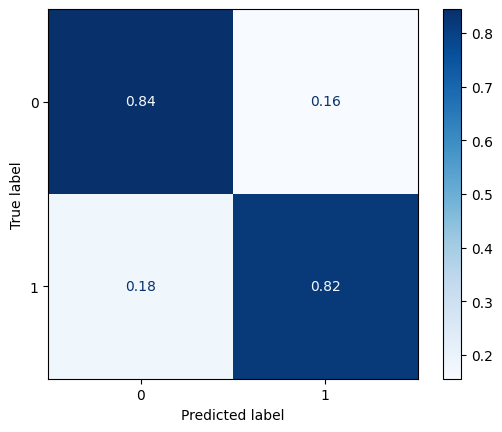

In [26]:
y_true ,y_pred =evaluate_on_test(GRU_model, test_loader)

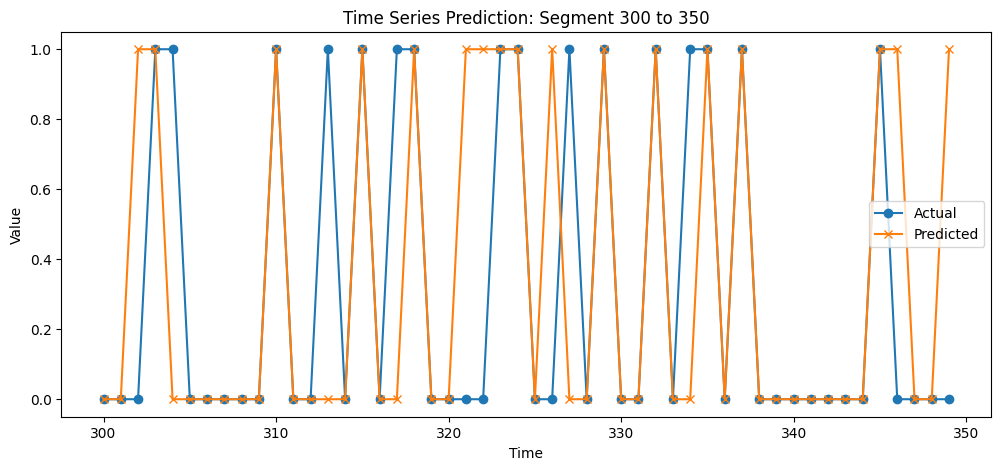

In [28]:
start = 300  # Starting index of segment
end = 350    # Ending index (exclusive)

# If y_true, y_pred are numpy arrays or lists:
time_segment = np.arange(start, end)
y_true_segment = y_true[start:end]
y_pred_segment = y_pred[start:end]

plt.figure(figsize=(12,5))
plt.plot(time_segment, y_true_segment, label='Actual', marker='o')
plt.plot(time_segment, y_pred_segment, label='Predicted', marker='x')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'Time Series Prediction: Segment {start} to {end}')
plt.legend()
plt.show()
